In [1]:
# Biblioteca para operações numéricas
import numpy as np

# Para visualização
import matplotlib.pyplot as plt

# Para redes neurais
import tensorflow as tf

# Interface de alto nível para redes neurais
from tensorflow import keras

# Importando as camadas de rede
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Flatten, Dense, Dropout

# Funções utilitárias para trabalhar com imagens
from tensorflow.keras.utils import load_img, img_to_array

# Carregar a base de Dados CIFAR-10

In [2]:
# Carregar a base CIFAR
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar os valores para um intervalo [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ["avião", "automóvel", "pássaro", "gato", "cervo", "cachorro", "sapo", "cavalo", "navio", "caminhão"]

print(f"Formato de x_train:", x_train.shape)
print(f"Formato de y_train:", y_train.shape)
print(f"Formato de x_test:", x_test.shape)
print(f"Formato de y_test:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Formato de x_train: (60000, 28, 28)
Formato de y_train: (60000,)
Formato de x_test: (10000, 28, 28)
Formato de y_test: (10000,)


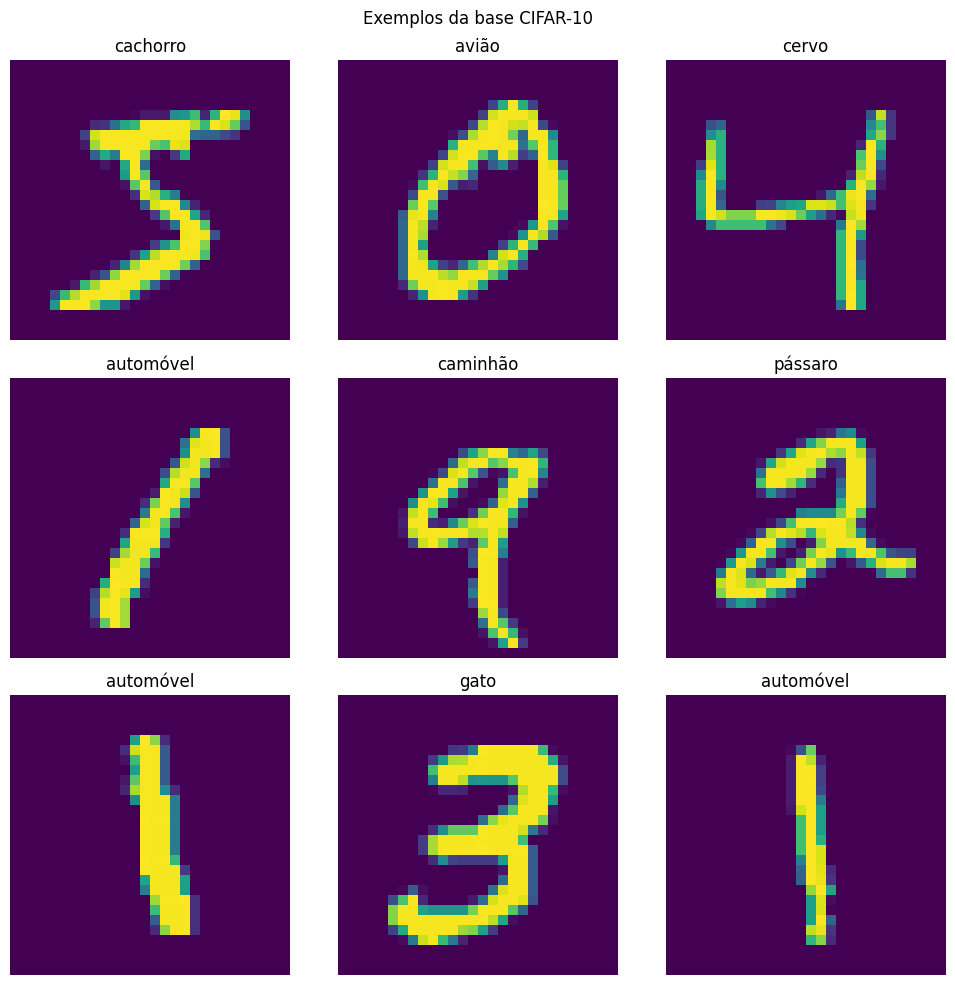

In [4]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.suptitle("Exemplos da base CIFAR-10")
plt.tight_layout()
plt.show()

# Criação do Modelo CNN

In [5]:
model = keras.Sequential()

# Camada de entrada
model.add(Input(shape=(32, 32, 3)))

# Bloco 1
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 2
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 3
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Transição CNN => DENSE (Totalmente conectada)7
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(Dense(10, activation="softmax"))

# Compilar
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,682 (158.91 KB)

 Trainable params: 40,682 (158.91 KB)

 Non-trainable params: 0 (0.00 B)

# Treinar a rede

In [6]:
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)



Epoch 1/10


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(64, 28, 28), dtype=float32) with name 'keras_tensor' and path ''. Expected shape (None, 32, 32, 3), but input has incompatible shape (64, 28, 28)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(64, 28, 28), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia por época')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss por época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>